<a href="https://colab.research.google.com/github/traceswrldd/traceswrldd/blob/main/W3_internship.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Diabetes_Classification.csv')

In [3]:
df.head()

,Age,Gender,BMI,Blood Pressure,FBS,HbA1c,Family History of Diabetes,Smoking,Diet,Exercise,Diagnosis
0,45,Male,25.0,Normal,100,5.7,No,No,Healthy,Regular,No
1,55,Female,30.0,High,120,6.4,Yes,Yes,Poor,No,Yes
2,65,Male,35.0,High,140,7.1,Yes,Yes,Poor,No,Yes
3,75,Female,40.0,High,160,7.8,Yes,Yes,Poor,No,Yes
4,40,Male,20.0,Normal,80,5.0,No,No,Healthy,NaN,No


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128 entries, 0 to 127
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         128 non-null    int64  
 1   Gender                      128 non-null    object 
 2   BMI                         125 non-null    float64
 3   Blood Pressure              128 non-null    object 
 4   FBS                         128 non-null    int64  
 5   HbA1c                       128 non-null    float64
 6   Family History of Diabetes  126 non-null    object 
 7   Smoking                     126 non-null    object 
 8   Diet                        126 non-null    object 
 9   Exercise                    127 non-null    object 
 10  Diagnosis                   128 non-null    object 
dtypes: float64(2), int64(2), object(7)
memory usage: 11.1+ KB


In [5]:
df.isnull().sum()

,0
Age,0
Gender,0
BMI,3
Blood Pressure,0
FBS,0
HbA1c,0
Family History of Diabetes,2
Smoking,2
Diet,2
Exercise,1


In [6]:
df=df.dropna()

In [7]:
df.head()

,Age,Gender,BMI,Blood Pressure,FBS,HbA1c,Family History of Diabetes,Smoking,Diet,Exercise,Diagnosis
0,45,Male,25.0,Normal,100,5.7,No,No,Healthy,Regular,No
1,55,Female,30.0,High,120,6.4,Yes,Yes,Poor,No,Yes
2,65,Male,35.0,High,140,7.1,Yes,Yes,Poor,No,Yes
3,75,Female,40.0,High,160,7.8,Yes,Yes,Poor,No,Yes
5,50,Female,25.0,Normal,100,5.7,No,No,Healthy,Regular,No


#Problems with categorical values in columns:

In [8]:
#label encoding
from sklearn.preprocessing import LabelEncoder
cat_col=['Diagnosis']

le=LabelEncoder()

for col in cat_col:
    df[col]=le.fit_transform(df[col])

df.head()

,Age,Gender,BMI,Blood Pressure,FBS,HbA1c,Family History of Diabetes,Smoking,Diet,Exercise,Diagnosis
0,45,Male,25.0,Normal,100,5.7,No,No,Healthy,Regular,0
1,55,Female,30.0,High,120,6.4,Yes,Yes,Poor,No,1
2,65,Male,35.0,High,140,7.1,Yes,Yes,Poor,No,1
3,75,Female,40.0,High,160,7.8,Yes,Yes,Poor,No,1
5,50,Female,25.0,Normal,100,5.7,No,No,Healthy,Regular,0


In [17]:
#one hot encoding
one_encoded= pd.get_dummies(df,columns=['Gender'])
one_encoded.head()

,Age,BMI,Blood Pressure,FBS,HbA1c,Family History of Diabetes,Smoking,Diet,Exercise,Diagnosis,Gender_Female,Gender_Male
0,45,25.0,Normal,100,5.7,No,No,Healthy,Regular,0,False,True
1,55,30.0,High,120,6.4,Yes,Yes,Poor,No,1,True,False
2,65,35.0,High,140,7.1,Yes,Yes,Poor,No,1,False,True
3,75,40.0,High,160,7.8,Yes,Yes,Poor,No,1,True,False
5,50,25.0,Normal,100,5.7,No,No,Healthy,Regular,0,True,False


In [19]:
#one hot encoding
one_encoded= pd.get_dummies(df,columns=['Gender'])
one_encoded.head()

,Age,BMI,Blood Pressure,FBS,HbA1c,Family History of Diabetes,Smoking,Diet,Exercise,Diagnosis,Gender_Female,Gender_Male
0,45,25.0,Normal,100,5.7,No,No,Healthy,Regular,0,False,True
1,55,30.0,High,120,6.4,Yes,Yes,Poor,No,1,True,False
2,65,35.0,High,140,7.1,Yes,Yes,Poor,No,1,False,True
3,75,40.0,High,160,7.8,Yes,Yes,Poor,No,1,True,False
5,50,25.0,Normal,100,5.7,No,No,Healthy,Regular,0,True,False


how to choose either label encoding or onehot encoding:
it depends on the type of categorical variable:
label encoding: when values in features are ordinal: order Ex: Education - Bachelors>Masters>Doctorate
Onehotending: When categories are not in order (Nominal Values):  Gender- Male, Female, Smoking etc

In [20]:
#we are applying one hot encoding

cat_col=['Gender','Exercise','Blood Pressure', 'Family History of Diabetes', 'Smoking', 'Diet']

one_encoded= pd.get_dummies(df,columns=cat_col)

In [21]:
one_encoded.head()

,Age,BMI,FBS,HbA1c,Diagnosis,Gender_Female,Gender_Male,Exercise_No,Exercise_Regular,Blood Pressure_High,Blood Pressure_Low,Blood Pressure_Normal,Family History of Diabetes_No,Family History of Diabetes_Yes,Smoking_No,Smoking_Yes,Diet_Healthy,Diet_Poor
0,45,25.0,100,5.7,0,False,True,False,True,False,False,True,True,False,True,False,True,False
1,55,30.0,120,6.4,1,True,False,True,False,True,False,False,False,True,False,True,False,True
2,65,35.0,140,7.1,1,False,True,True,False,True,False,False,False,True,False,True,False,True
3,75,40.0,160,7.8,1,True,False,True,False,True,False,False,False,True,False,True,False,True
5,50,25.0,100,5.7,0,True,False,False,True,False,False,True,True,False,True,False,True,False


In [22]:
#label encoding the one hot encoded columns to convert all the string values in newly generated columns to integers
cat_col=[ 'Gender_Female',
       'Gender_Male', 'Exercise_No', 'Exercise_Regular', 'Blood Pressure_High',
       'Blood Pressure_Low', 'Blood Pressure_Normal',
       'Family History of Diabetes_No', 'Family History of Diabetes_Yes',
       'Smoking_No', 'Smoking_Yes', 'Diet_Healthy', 'Diet_Poor']
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
for col in cat_col:
    one_encoded[col]=le.fit_transform(one_encoded[col])

In [23]:
one_encoded.head()

,Age,BMI,FBS,HbA1c,Diagnosis,Gender_Female,Gender_Male,Exercise_No,Exercise_Regular,Blood Pressure_High,Blood Pressure_Low,Blood Pressure_Normal,Family History of Diabetes_No,Family History of Diabetes_Yes,Smoking_No,Smoking_Yes,Diet_Healthy,Diet_Poor
0,45,25.0,100,5.7,0,0,1,0,1,0,0,1,1,0,1,0,1,0
1,55,30.0,120,6.4,1,1,0,1,0,1,0,0,0,1,0,1,0,1
2,65,35.0,140,7.1,1,0,1,1,0,1,0,0,0,1,0,1,0,1
3,75,40.0,160,7.8,1,1,0,1,0,1,0,0,0,1,0,1,0,1
5,50,25.0,100,5.7,0,1,0,0,1,0,0,1,1,0,1,0,1,0


EDA

In [24]:
#Feature Selection: Removing irrelevant features which does not contribute towards the label(Diagnosis)
#defining feature selection model
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k=5)

In [25]:
#splitting label and features
x=one_encoded.drop('Diagnosis', axis=1)
y=one_encoded['Diagnosis']

In [26]:
#applying feature selection
x_selected=selector.fit_transform(x,y)
selected_features=x.columns[selector.get_support()]
print(selected_features)

Index(['Exercise_Regular', 'Smoking_No', 'Smoking_Yes', 'Diet_Healthy',
       'Diet_Poor'],
      dtype='object')


In [27]:
#created df with selected features
x1=one_encoded[selected_features]

In [28]:
#train test split
from sklearn.model_selection import train_test_split

#for all features
x_train, x_test, y_train, y_test=train_test_split(x,y,test_size=0.4,random_state=10)

In [29]:
#for selected features
x1_train, x1_test, y_train, y_test=train_test_split(x,y,test_size=0.4,random_state=10)

In [87]:
#building knn models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

In [88]:
#training models
#all features
model=KNeighborsClassifier()
model.fit(x_train,y_train)

#selected features
model1=KNeighborsClassifier()
model1.fit(x1_train,y_train)

KNeighborsClassifier()

In [89]:
#classification report
#all features
y_pred=model.predict(x_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.82      0.69      0.75        39
           1       0.20      0.33      0.25         9

    accuracy                           0.62        48
   macro avg       0.51      0.51      0.50        48
weighted avg       0.70      0.62      0.66        48



In [30]:
#building xgboost models
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report


In [31]:
#training models
#all features
model=xgb.XGBClassifier()
model.fit(x_train,y_train)

#selected features
model1=xgb.XGBClassifier()
model1.fit(x1_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [32]:
#classification report
#all features
y_pred=model.predict(x_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.93      1.00      0.96        39
           1       1.00      0.67      0.80         9

    accuracy                           0.94        48
   macro avg       0.96      0.83      0.88        48
weighted avg       0.94      0.94      0.93        48



In [43]:
#building svm models
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report


In [50]:
#training models
#all features
model=SVC(probability=True)
model.fit(x_train,y_train)

#selected features
model1=SVC()
model1.fit(x1_train,y_train)

SVC()

In [45]:
#classification report
from sklearn.metrics import accuracy_score, classification_report
#all features
y_pred=model.predict(x_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.81      1.00      0.90        39
           1       0.00      0.00      0.00         9

    accuracy                           0.81        48
   macro avg       0.41      0.50      0.45        48
weighted avg       0.66      0.81      0.73        48



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


<Axes: >

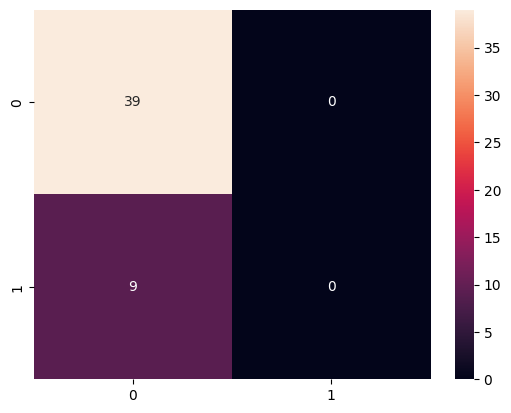

In [47]:
#confusion: it show labelwise performance of the model

from sklearn.metrics import confusion_matrix

cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True)

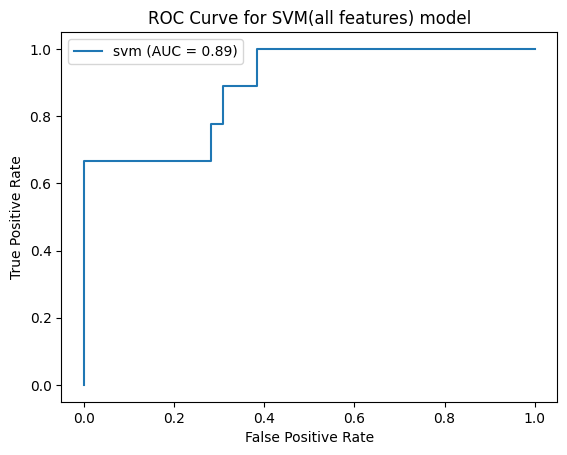

In [51]:
#plot ROC curve for svm all features model
from sklearn.metrics import roc_auc_score, roc_curve

y_proba = model.predict_proba(x_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f'{"svm"} (AUC = {roc_auc_score(y_test, y_proba):.2f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for SVM(all features) model')
plt.legend()
plt.show()

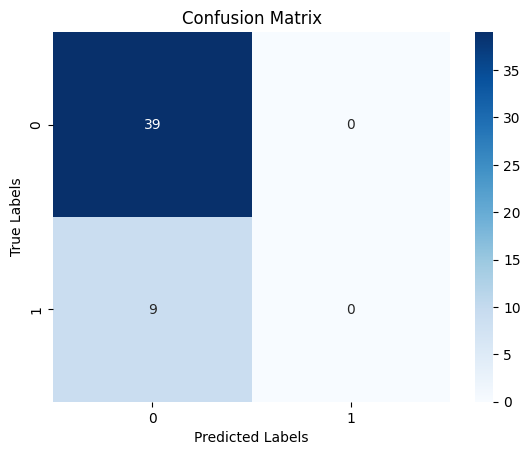

In [58]:
#Plot confusion matrix and ROC curves for xgboost model
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

#plot confusion matrix for xgboost
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()


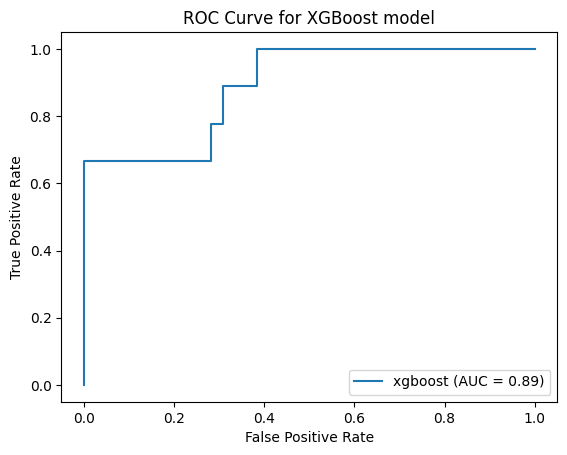

In [60]:
#plot ROC curve for xgboost
y_proba = model.predict_proba(x_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f'{"xgboost"} (AUC = {roc_auc_score(y_test, y_proba):.2f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for XGBoost model')
plt.legend()
plt.show()

In [62]:
#Compare the performance(accuracy, f1 score etc) of xgboost and svm models created using graph plots

import matplotlib.pyplot as plt
import numpy as np

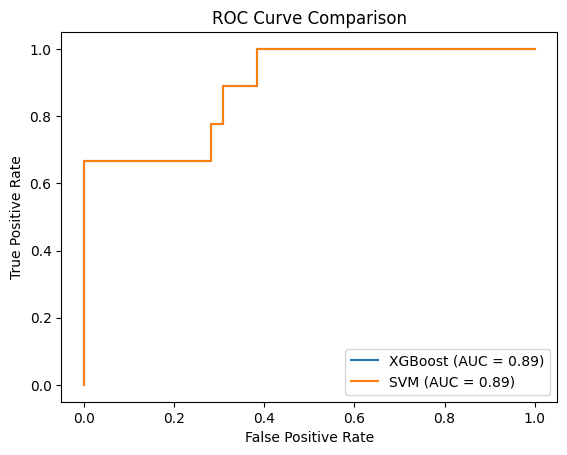

In [68]:
#the performance(accuracy, f1 score etc) of xgboost model created using graph plots
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

xgb_accuracy = accuracy_score(y_test, y_pred)
xgb_f1_score = f1_score(y_test, y_pred, zero_division=1)
xgb_precision = precision_score(y_test, y_pred, zero_division=1)
xgb_recall = recall_score(y_test, y_pred)

plt.plot(fpr, tpr, label=f'XGBoost (AUC = {roc_auc_score(y_test, y_proba):.2f})')
plt.plot(fpr, tpr, label=f'SVM (AUC = {roc_auc_score(y_test, y_proba):.2f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()



In [78]:
# Calculate performance metrics for the SVM model
svm_accuracy = accuracy_score(y_test, model.predict(x_test))
svm_f1_score = f1_score(y_test, model.predict(x_test), zero_division=1)
svm_precision = precision_score(y_test, model.predict(x_test), zero_division=1)
svm_recall = recall_score(y_test, model.predict(x_test))

print("SVM Model Metrics:")
print(f"Accuracy: {svm_accuracy:.2f}")
print(f"F1 Score: {svm_f1_score:.2f}")
print(f"Precision: {svm_precision:.2f}")
print(f"Recall: {svm_recall:.2f}")

SVM Model Metrics:
Accuracy: 0.81
F1 Score: 0.00
Precision: 1.00
Recall: 0.00


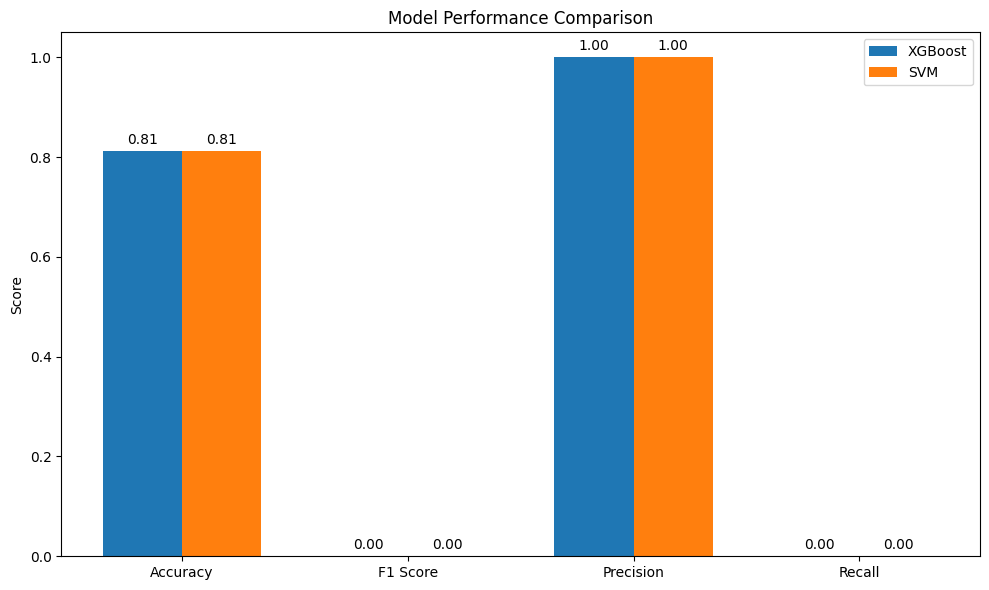

In [80]:
# Plot the performance metrics for XGBoost and SVM
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

# Data for plotting
metrics_labels = ['Accuracy', 'F1 Score', 'Precision', 'Recall']
xgb_metrics = [xgb_accuracy, xgb_f1_score, xgb_precision, xgb_recall]
svm_metrics = [svm_accuracy, svm_f1_score, svm_precision, svm_recall]

x = np.arange(len(metrics_labels))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, xgb_metrics, width, label='XGBoost')
rects2 = ax.bar(x + width/2, svm_metrics, width, label='SVM')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(metrics_labels)
ax.legend()

def autolabel(rects):
    """Attach a text label above each bar in *rects*, displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate('%.2f' % height,
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

fig.tight_layout()

plt.show()

In [81]:
#label coding
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['Gender']=le.fit_transform(df['Gender'])
df.head()

,Age,Gender,BMI,Blood Pressure,FBS,HbA1c,Family History of Diabetes,Smoking,Diet,Exercise,Diagnosis
0,45,1,25.0,Normal,100,5.7,No,No,Healthy,Regular,0
1,55,0,30.0,High,120,6.4,Yes,Yes,Poor,No,1
2,65,1,35.0,High,140,7.1,Yes,Yes,Poor,No,1
3,75,0,40.0,High,160,7.8,Yes,Yes,Poor,No,1
5,50,0,25.0,Normal,100,5.7,No,No,Healthy,Regular,0


In [82]:
#label coding
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['Exercise']=le.fit_transform(df['Exercise'])
df.head()

,Age,Gender,BMI,Blood Pressure,FBS,HbA1c,Family History of Diabetes,Smoking,Diet,Exercise,Diagnosis
0,45,1,25.0,Normal,100,5.7,No,No,Healthy,1,0
1,55,0,30.0,High,120,6.4,Yes,Yes,Poor,0,1
2,65,1,35.0,High,140,7.1,Yes,Yes,Poor,0,1
3,75,0,40.0,High,160,7.8,Yes,Yes,Poor,0,1
5,50,0,25.0,Normal,100,5.7,No,No,Healthy,1,0


In [83]:
#label coding
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['Blood Pressure']=le.fit_transform(df['Blood Pressure'])
df.head()

,Age,Gender,BMI,Blood Pressure,FBS,HbA1c,Family History of Diabetes,Smoking,Diet,Exercise,Diagnosis
0,45,1,25.0,2,100,5.7,No,No,Healthy,1,0
1,55,0,30.0,0,120,6.4,Yes,Yes,Poor,0,1
2,65,1,35.0,0,140,7.1,Yes,Yes,Poor,0,1
3,75,0,40.0,0,160,7.8,Yes,Yes,Poor,0,1
5,50,0,25.0,2,100,5.7,No,No,Healthy,1,0


In [84]:
#label coding
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['Family History of Diabetes']=le.fit_transform(df['Family History of Diabetes'])
df.head()

,Age,Gender,BMI,Blood Pressure,FBS,HbA1c,Family History of Diabetes,Smoking,Diet,Exercise,Diagnosis
0,45,1,25.0,2,100,5.7,0,No,Healthy,1,0
1,55,0,30.0,0,120,6.4,1,Yes,Poor,0,1
2,65,1,35.0,0,140,7.1,1,Yes,Poor,0,1
3,75,0,40.0,0,160,7.8,1,Yes,Poor,0,1
5,50,0,25.0,2,100,5.7,0,No,Healthy,1,0


In [85]:
#label coding
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['Smoking']=le.fit_transform(df['Smoking'])
df.head()

,Age,Gender,BMI,Blood Pressure,FBS,HbA1c,Family History of Diabetes,Smoking,Diet,Exercise,Diagnosis
0,45,1,25.0,2,100,5.7,0,0,Healthy,1,0
1,55,0,30.0,0,120,6.4,1,1,Poor,0,1
2,65,1,35.0,0,140,7.1,1,1,Poor,0,1
3,75,0,40.0,0,160,7.8,1,1,Poor,0,1
5,50,0,25.0,2,100,5.7,0,0,Healthy,1,0


In [86]:
#label coding
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['Diet']=le.fit_transform(df['Diet'])
df.head()

,Age,Gender,BMI,Blood Pressure,FBS,HbA1c,Family History of Diabetes,Smoking,Diet,Exercise,Diagnosis
0,45,1,25.0,2,100,5.7,0,0,0,1,0
1,55,0,30.0,0,120,6.4,1,1,1,0,1
2,65,1,35.0,0,140,7.1,1,1,1,0,1
3,75,0,40.0,0,160,7.8,1,1,1,0,1
5,50,0,25.0,2,100,5.7,0,0,0,1,0
